Лабораторна робота: Побудова та оцінка класифікаційних моделей з використанням ансамблів
Мета роботи
Вивчити методи побудови класифікаційних моделей, попередньої обробки даних, використання ансамблевих методів та оцінки моделей.
Завдання
1.	Вибір навчального набору даних
o	Оберіть навчальний набір даних для класифікатора на свій розсуд. Для цього можна скористатися платформою Kaggle (наприклад, Kaggle Datasets).
o	Завантажте та досліджуйте обраний набір даних.

5.	Оцінка моделей
o	Для кожного класифікатора та ансамблю побудуйте та оцініть:
	Матрицю невідповідностей (confusion matrix)
	Точність (accuracy)
	Прецизію (precision)
	Повторюваність (recall)
	F1-оцінку (F1-score)
6.	Побудова ROC кривих
o	Побудуйте ROC криві для всіх класифікаторів та їх ансамблів.
o	Оцініть краще з них за допомогою площі під кривою (AUC - Area Under Curve).


In [13]:
import pandas as pd

#Loading file as dataframe
file_path = 'iris.csv'
df = pd.read_csv(file_path)

2.	Попередня обробка даних

o	Виконайте очищення даних (обробка пропущених значень, видалення дублікатів тощо).

o	Виконайте нормалізацію або стандартизацію числових змінних (якщо необхідно).

o	Виконайте перетворення категоріальних змінних (наприклад, One-Hot Encoding).

o	Збалансуйте набір даних.

o	Розділіть набір даних на навчальну та тестову вибірки.

In [14]:
pd.set_option('display.max_colwidth', None) 
pd.set_option('display.expand_frame_repr', False) 
pd.set_option('display.max_columns', None)  

# Display the first 10 rows
print("First 10 rows of the dataset:")
print(df.head(10))

First 10 rows of the dataset:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
5   6            5.4           3.9            1.7           0.4  Iris-setosa
6   7            4.6           3.4            1.4           0.3  Iris-setosa
7   8            5.0           3.4            1.5           0.2  Iris-setosa
8   9            4.4           2.9            1.4           0.2  Iris-setosa
9  10            4.9           3.1            1.5           0.1  Iris-setosa


In [15]:
#Check for missing values
print("\nChecking for missing values in each column:")
print(df.isnull().sum())


Checking for missing values in each column:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [16]:
#Check for duplicate rows
print("\nChecking for duplicate rows:")
print(f"Number of duplicate rows: {df.duplicated().sum()}")


Checking for duplicate rows:
Number of duplicate rows: 0


In [17]:
#Drop the 'Id' column because it does not contribute to classification
print("\nDropping the 'Id' column...")
df = df.drop(columns=['Id'])
print(f"Shape of dataset after dropping 'Id' column: {df.shape}")


Dropping the 'Id' column...
Shape of dataset after dropping 'Id' column: (150, 5)


In [18]:
#Final view of cleaned dataset
print("\nFirst 5 rows of the cleaned dataset:")
print(df.head())


First 5 rows of the cleaned dataset:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0            5.1           3.5            1.4           0.2  Iris-setosa
1            4.9           3.0            1.4           0.2  Iris-setosa
2            4.7           3.2            1.3           0.2  Iris-setosa
3            4.6           3.1            1.5           0.2  Iris-setosa
4            5.0           3.6            1.4           0.2  Iris-setosa


In [19]:
from sklearn.preprocessing import MinMaxScaler

# Create a MinMaxScaler object
scaler = MinMaxScaler()

# Select numeric features to normalize
numeric_features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

# Fit the scaler and transform the data
df[numeric_features] = scaler.fit_transform(df[numeric_features])

# Display the first 5 rows after normalization
print("First 5 rows after normalization:")
print(df.head())


First 5 rows after normalization:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0       0.222222      0.625000       0.067797      0.041667  Iris-setosa
1       0.166667      0.416667       0.067797      0.041667  Iris-setosa
2       0.111111      0.500000       0.050847      0.041667  Iris-setosa
3       0.083333      0.458333       0.084746      0.041667  Iris-setosa
4       0.194444      0.666667       0.067797      0.041667  Iris-setosa


In [20]:
from sklearn.preprocessing import LabelEncoder

# Create a LabelEncoder object
label_encoder = LabelEncoder()

# Fit the LabelEncoder and transform the 'Species' column
df['Species'] = label_encoder.fit_transform(df['Species'])

# Display the first 5 rows after label encoding
print("First 5 rows after Label Encoding:")
print(df.head())

# Optional: Display the mapping between labels and original species
print("\nMapping of species labels:")
for idx, class_name in enumerate(label_encoder.classes_):
    print(f"{idx} -> {class_name}")

First 5 rows after Label Encoding:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  Species
0       0.222222      0.625000       0.067797      0.041667        0
1       0.166667      0.416667       0.067797      0.041667        0
2       0.111111      0.500000       0.050847      0.041667        0
3       0.083333      0.458333       0.084746      0.041667        0
4       0.194444      0.666667       0.067797      0.041667        0

Mapping of species labels:
0 -> Iris-setosa
1 -> Iris-versicolor
2 -> Iris-virginica


In [ ]:
# Count the number of samples in each class
print("Class distribution in the dataset:")
print(df['Species'].value_counts())

Class distribution in the dataset:
Species
0    50
1    50
2    50
Name: count, dtype: int64


In [22]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop('Species', axis=1)  # Features (input variables)
y = df['Species']               # Target (output variable)

# Split the dataset: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Display the shapes of the splits
print("Shape of training features:", X_train.shape)
print("Shape of training labels:", y_train.shape)
print("Shape of testing features:", X_test.shape)
print("Shape of testing labels:", y_test.shape)

Shape of training features: (120, 4)
Shape of training labels: (120,)
Shape of testing features: (30, 4)
Shape of testing labels: (30,)


3.	Побудова класифікаційних моделей

o	Побудуйте декілька класифікаційних моделей, таких як:

	Логістична регресія

o	Навчіть моделі на навчальній вибірці та протестуйте на тестовій вибірці.

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# Create and train the Logistic Regression model
logreg_model = LogisticRegression(max_iter=200, random_state=42)
logreg_model.fit(X_train, y_train)

# Make predictions
y_pred_logreg = logreg_model.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_logreg))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logreg, digits=4))


Confusion Matrix:
[[10  0  0]
 [ 0  8  2]
 [ 0  1  9]]

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        10
           1     0.8889    0.8000    0.8421        10
           2     0.8182    0.9000    0.8571        10

    accuracy                         0.9000        30
   macro avg     0.9024    0.9000    0.8997        30
weighted avg     0.9024    0.9000    0.8997        30



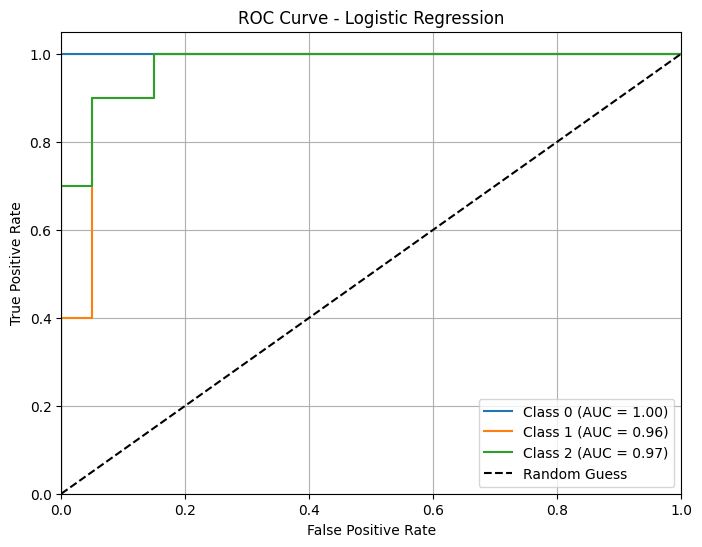

In [24]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Binarize the output for multi-class ROC
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2])

# Predict probabilities
y_score = logreg_model.predict_proba(X_test)

# Number of classes
n_classes = y_test_binarized.shape[1]

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc="lower right")
plt.grid()
plt.show()



	Дерево рішень

In [25]:
from sklearn.tree import DecisionTreeClassifier

# Create and train the Decision Tree model
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

# Make predictions
y_pred_tree = tree_model.predict(X_test)

# Evaluate the model
print("Confusion Matrix (Decision Tree):")
print(confusion_matrix(y_test, y_pred_tree))

print("\nClassification Report (Decision Tree):")
print(classification_report(y_test, y_pred_tree, digits=4))

Confusion Matrix (Decision Tree):
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Classification Report (Decision Tree):
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        10
           1     0.9000    0.9000    0.9000        10
           2     0.9000    0.9000    0.9000        10

    accuracy                         0.9333        30
   macro avg     0.9333    0.9333    0.9333        30
weighted avg     0.9333    0.9333    0.9333        30



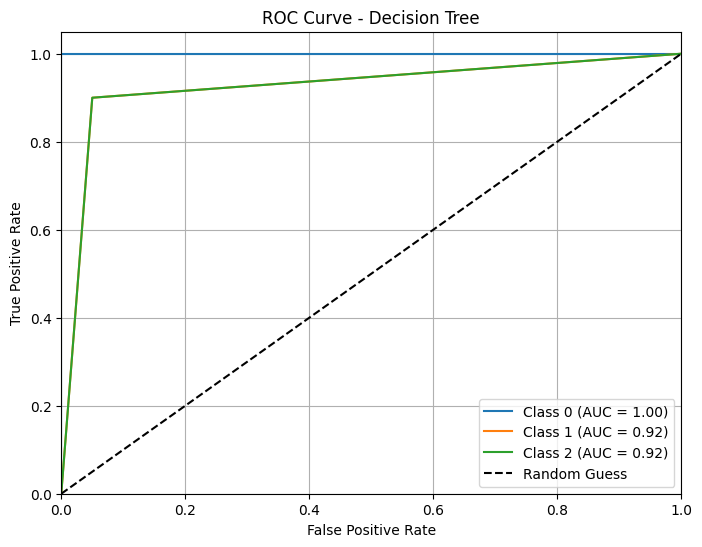

In [26]:
# Binarize the test labels for multi-class ROC
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2])

# Predict probabilities
y_score_tree = tree_model.predict_proba(X_test)

# Number of classes
n_classes = y_test_binarized.shape[1]

# Compute ROC curves and AUC for each class
fpr_tree = dict()
tpr_tree = dict()
roc_auc_tree = dict()

for i in range(n_classes):
    fpr_tree[i], tpr_tree[i], _ = roc_curve(y_test_binarized[:, i], y_score_tree[:, i])
    roc_auc_tree[i] = auc(fpr_tree[i], tpr_tree[i])

# Plot ROC curves
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr_tree[i], tpr_tree[i], label=f"Class {i} (AUC = {roc_auc_tree[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree')
plt.legend(loc="lower right")
plt.grid()
plt.show()

	Підтримковий векторний класифікатор (SVC)

In [27]:
from sklearn.svm import SVC

# Create and train the SVC model with probability estimates enabled
svc_model = SVC(probability=True, random_state=42)
svc_model.fit(X_train, y_train)

# Make predictions
y_pred_svc = svc_model.predict(X_test)

# Evaluate the model
print("Confusion Matrix (SVC):")
print(confusion_matrix(y_test, y_pred_svc))

print("\nClassification Report (SVC):")
print(classification_report(y_test, y_pred_svc, digits=4))


Confusion Matrix (SVC):
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report (SVC):
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        10
           1     1.0000    0.9000    0.9474        10
           2     0.9091    1.0000    0.9524        10

    accuracy                         0.9667        30
   macro avg     0.9697    0.9667    0.9666        30
weighted avg     0.9697    0.9667    0.9666        30



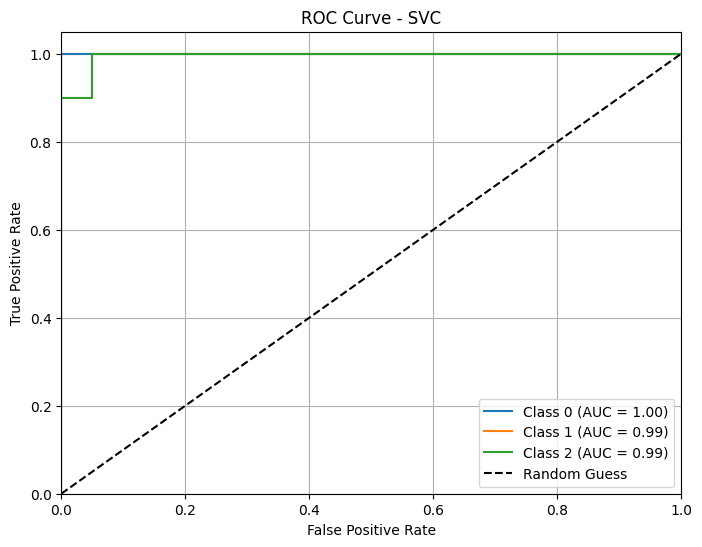

In [28]:
# Binarize the test labels for multi-class ROC
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2])

# Predict probabilities
y_score_svc = svc_model.predict_proba(X_test)

# Number of classes
n_classes = y_test_binarized.shape[1]

# Compute ROC curves and AUC for each class
fpr_svc = dict()
tpr_svc = dict()
roc_auc_svc = dict()

for i in range(n_classes):
    fpr_svc[i], tpr_svc[i], _ = roc_curve(y_test_binarized[:, i], y_score_svc[:, i])
    roc_auc_svc[i] = auc(fpr_svc[i], tpr_svc[i])

# Plot ROC curves
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr_svc[i], tpr_svc[i], label=f"Class {i} (AUC = {roc_auc_svc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVC')
plt.legend(loc="lower right")
plt.grid()
plt.show()


	K-найближчих сусідів (KNN)

In [29]:
from sklearn.neighbors import KNeighborsClassifier

# Create and train the KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)  # You can adjust n_neighbors
knn_model.fit(X_train, y_train)

# Make predictions
y_pred_knn = knn_model.predict(X_test)

# Evaluate the model
print("Confusion Matrix (KNN):")
print(confusion_matrix(y_test, y_pred_knn))

print("\nClassification Report (KNN):")
print(classification_report(y_test, y_pred_knn, digits=4))

Confusion Matrix (KNN):
[[10  0  0]
 [ 0 10  0]
 [ 0  1  9]]

Classification Report (KNN):
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        10
           1     0.9091    1.0000    0.9524        10
           2     1.0000    0.9000    0.9474        10

    accuracy                         0.9667        30
   macro avg     0.9697    0.9667    0.9666        30
weighted avg     0.9697    0.9667    0.9666        30



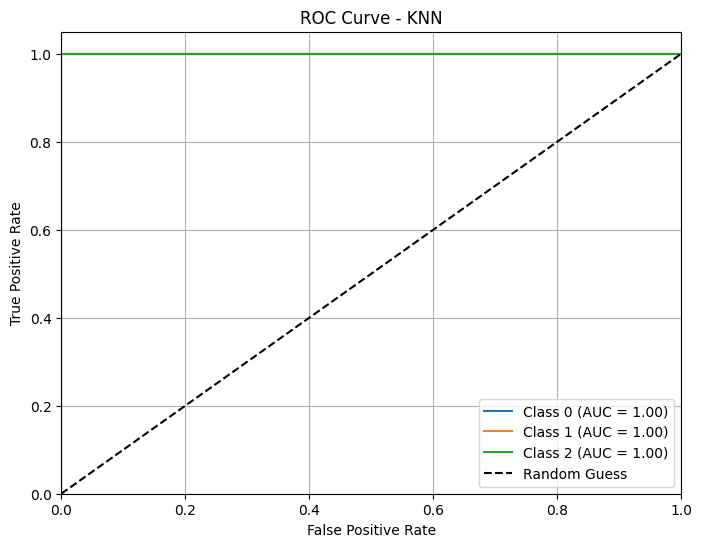

In [30]:
# Binarize the test labels for multi-class ROC
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2])

# Predict probabilities
y_score_knn = knn_model.predict_proba(X_test)

# Number of classes
n_classes = y_test_binarized.shape[1]

# Compute ROC curves and AUC for each class
fpr_knn = dict()
tpr_knn = dict()
roc_auc_knn = dict()

for i in range(n_classes):
    fpr_knn[i], tpr_knn[i], _ = roc_curve(y_test_binarized[:, i], y_score_knn[:, i])
    roc_auc_knn[i] = auc(fpr_knn[i], tpr_knn[i])

# Plot ROC curves
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr_knn[i], tpr_knn[i], label=f"Class {i} (AUC = {roc_auc_knn[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - KNN')
plt.legend(loc="lower right")
plt.grid()
plt.show()

	Наївний баєсів класифікатор

In [31]:
from sklearn.naive_bayes import GaussianNB

# Create and train the Naive Bayes model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Make predictions
y_pred_nb = nb_model.predict(X_test)

# Evaluate the model
print("Confusion Matrix (Naive Bayes):")
print(confusion_matrix(y_test, y_pred_nb))

print("\nClassification Report (Naive Bayes):")
print(classification_report(y_test, y_pred_nb, digits=4))

Confusion Matrix (Naive Bayes):
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report (Naive Bayes):
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        10
           1     1.0000    0.9000    0.9474        10
           2     0.9091    1.0000    0.9524        10

    accuracy                         0.9667        30
   macro avg     0.9697    0.9667    0.9666        30
weighted avg     0.9697    0.9667    0.9666        30



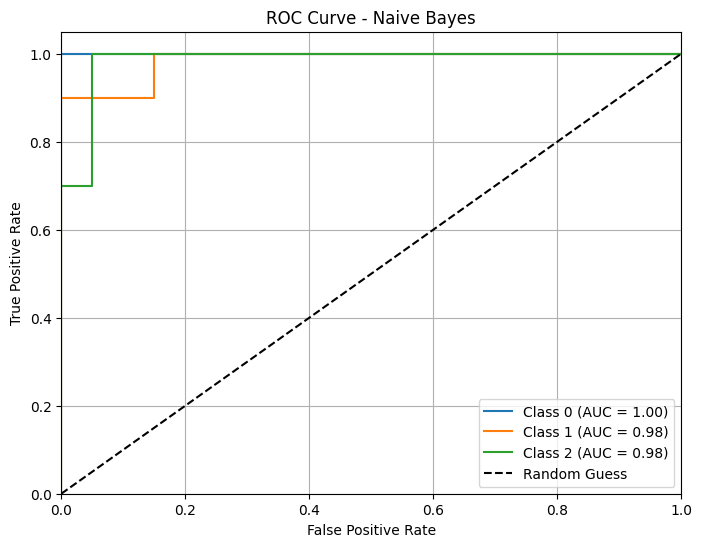

In [32]:
# Binarize the test labels for multi-class ROC
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2])

# Predict probabilities
y_score_nb = nb_model.predict_proba(X_test)

# Number of classes
n_classes = y_test_binarized.shape[1]

# Compute ROC curves and AUC for each class
fpr_nb = dict()
tpr_nb = dict()
roc_auc_nb = dict()

for i in range(n_classes):
    fpr_nb[i], tpr_nb[i], _ = roc_curve(y_test_binarized[:, i], y_score_nb[:, i])
    roc_auc_nb[i] = auc(fpr_nb[i], tpr_nb[i])

# Plot ROC curves
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr_nb[i], tpr_nb[i], label=f"Class {i} (AUC = {roc_auc_nb[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Naive Bayes')
plt.legend(loc="lower right")
plt.grid()
plt.show()

4.	Побудова ансамблів моделей
o	Побудуйте ансамбль моделей з використанням методів:
	Boosting (наприклад, AdaBoost, Gradient Boosting)

In [33]:
from sklearn.ensemble import AdaBoostClassifier

# Create and train the AdaBoost model
adaboost_model = AdaBoostClassifier(random_state=42)
adaboost_model.fit(X_train, y_train)

# Make predictions
y_pred_adaboost = adaboost_model.predict(X_test)

# Evaluate the model
print("Confusion Matrix (AdaBoost):")
print(confusion_matrix(y_test, y_pred_adaboost))

print("\nClassification Report (AdaBoost):")
print(classification_report(y_test, y_pred_adaboost, digits=4))

Confusion Matrix (AdaBoost):
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Classification Report (AdaBoost):
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        10
           1     0.9000    0.9000    0.9000        10
           2     0.9000    0.9000    0.9000        10

    accuracy                         0.9333        30
   macro avg     0.9333    0.9333    0.9333        30
weighted avg     0.9333    0.9333    0.9333        30



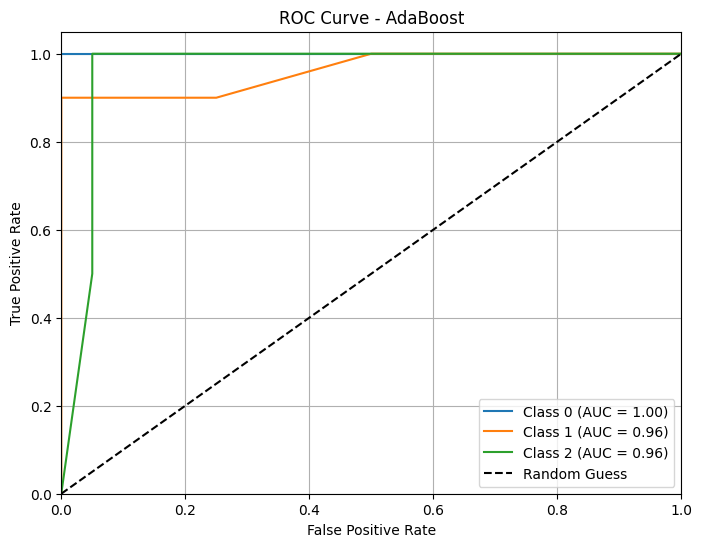

In [34]:
# Binarize the test labels for multi-class ROC
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2])

# Predict probabilities
y_score_adaboost = adaboost_model.predict_proba(X_test)

# Number of classes
n_classes = y_test_binarized.shape[1]

# Compute ROC curves and AUC for each class
fpr_adaboost = dict()
tpr_adaboost = dict()
roc_auc_adaboost = dict()

for i in range(n_classes):
    fpr_adaboost[i], tpr_adaboost[i], _ = roc_curve(y_test_binarized[:, i], y_score_adaboost[:, i])
    roc_auc_adaboost[i] = auc(fpr_adaboost[i], tpr_adaboost[i])

# Plot ROC curves
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr_adaboost[i], tpr_adaboost[i], label=f"Class {i} (AUC = {roc_auc_adaboost[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - AdaBoost')
plt.legend(loc="lower right")
plt.grid()
plt.show()

	Bagging (наприклад, Random Forest)

In [35]:
from sklearn.ensemble import RandomForestClassifier

# Create and train the Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
print("Confusion Matrix (Random Forest):")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf, digits=4))


Confusion Matrix (Random Forest):
[[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        10
           1     0.8182    0.9000    0.8571        10
           2     0.8889    0.8000    0.8421        10

    accuracy                         0.9000        30
   macro avg     0.9024    0.9000    0.8997        30
weighted avg     0.9024    0.9000    0.8997        30



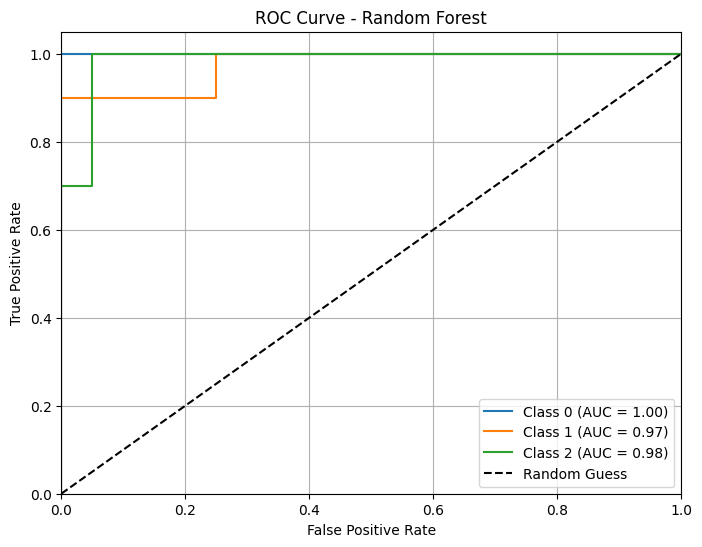

In [36]:
# Binarize the test labels for multi-class ROC
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2])

# Predict probabilities
y_score_rf = rf_model.predict_proba(X_test)

# Number of classes
n_classes = y_test_binarized.shape[1]

# Compute ROC curves and AUC for each class
fpr_rf = dict()
tpr_rf = dict()
roc_auc_rf = dict()

for i in range(n_classes):
    fpr_rf[i], tpr_rf[i], _ = roc_curve(y_test_binarized[:, i], y_score_rf[:, i])
    roc_auc_rf[i] = auc(fpr_rf[i], tpr_rf[i])

# Plot ROC curves
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr_rf[i], tpr_rf[i], label=f"Class {i} (AUC = {roc_auc_rf[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc="lower right")
plt.grid()
plt.show()

	Stacking (поєднання декількох базових моделей з використанням метамоделі)

In [38]:
from sklearn.ensemble import StackingClassifier

# Define base models
base_estimators = [
    ('decision_tree', DecisionTreeClassifier(random_state=42)),
    ('svc', SVC(probability=True, random_state=42))
]

# Define meta-model
meta_model = LogisticRegression(max_iter=200, random_state=42)

# Create and train the Stacking model
stacking_model = StackingClassifier(estimators=base_estimators, final_estimator=meta_model, cv=5)
stacking_model.fit(X_train, y_train)

# Make predictions
y_pred_stacking = stacking_model.predict(X_test)

# Evaluate the model
print("Confusion Matrix (Stacking):")
print(confusion_matrix(y_test, y_pred_stacking))

print("\nClassification Report (Stacking):")
print(classification_report(y_test, y_pred_stacking, digits=4))

Confusion Matrix (Stacking):
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report (Stacking):
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        10
           1     1.0000    0.9000    0.9474        10
           2     0.9091    1.0000    0.9524        10

    accuracy                         0.9667        30
   macro avg     0.9697    0.9667    0.9666        30
weighted avg     0.9697    0.9667    0.9666        30



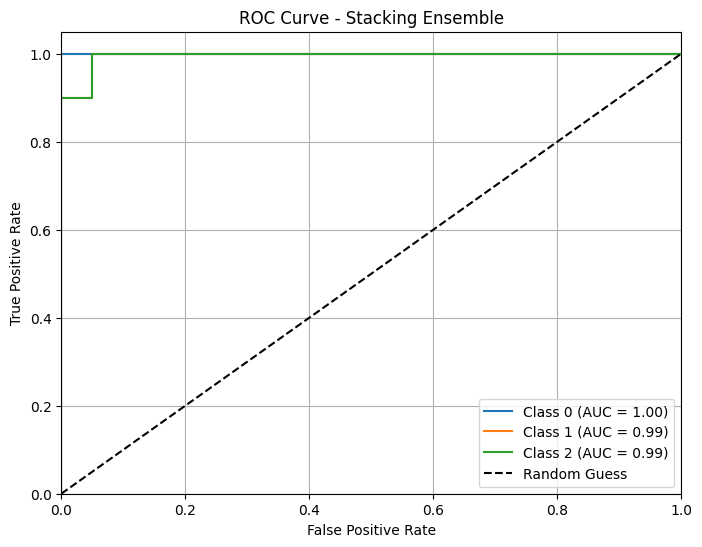

In [39]:
# Binarize the test labels for multi-class ROC
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2])

# Predict probabilities
y_score_stacking = stacking_model.predict_proba(X_test)

# Number of classes
n_classes = y_test_binarized.shape[1]

# Compute ROC curves and AUC for each class
fpr_stacking = dict()
tpr_stacking = dict()
roc_auc_stacking = dict()

for i in range(n_classes):
    fpr_stacking[i], tpr_stacking[i], _ = roc_curve(y_test_binarized[:, i], y_score_stacking[:, i])
    roc_auc_stacking[i] = auc(fpr_stacking[i], tpr_stacking[i])

# Plot ROC curves
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr_stacking[i], tpr_stacking[i], label=f"Class {i} (AUC = {roc_auc_stacking[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Stacking Ensemble')
plt.legend(loc="lower right")
plt.grid()
plt.show()